# 1. Business Understanding
Formula one(F1) is a motor racing championship founded in 1950. The 2026 season features a major set of regulation changes with a revised power unit configuration and new active aerodynamics. This new set of rules have made it difficult for teams to be certain turning it into a prediction opportunity. This project aims to build a predictive sports analytics solution that uses FastF1 2026 session data (practice, qualifying, and race results) to model driver performance and estimate the probability of winning the Miami Grand Prix. It also analyzes the 2026 season performance trends of drivers. The first few races are analyzed to determine which drivers and teams are fast, and that knowledge is used to make an educated, data-driven guess about who wins in Miami. 

### Main Objective:
 To build a machine learning model that predicts the Miami Grand Prix,2026 Winner and analyze drivers’ performance by comparing how their results evolve throughout the season.
### Objectives 
1. To analyze qualifying sessions performance (Q1, Q2, Q3) to identify potential winner. 
2. To identify driver performance trends across the season. 
3. To analyze the relationship between qualifying positions and race results in order to identify how starting position influences winning probability. 
4. To evaluate the model performance using precision and ROC-AUC curve 

#### Key stakeholders:
* Sports Analysts
* F1 fans 

# 2. Data Understanding

In [79]:
import fastf1
import warnings
import os
import pickle
import pandas as pd
import numpy as np
import requests
import fastf1.plotting
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer


In [80]:
#storing fastf1 data
fastf1.Cache.enable_cache("f1_cache")

In [81]:
def load_qualifying_data(season: int, event_name: str) -> pd.DataFrame:

    session = fastf1.get_session(season, event_name, "Q")
    session.load()
    results = session.results[
        ["DriverNumber", "Abbreviation", "TeamName", "Q1", "Q2", "Q3", "Position"]
    ].copy()
    results.rename(columns={"Abbreviation": "Driver", "TeamName": "Team"}, inplace=True)
    results["Event"] = event_name
    results["Season"] = season
    # Convert timedelta Q-times to seconds
    for q in ["Q1", "Q2", "Q3"]:
        results[f"{q}_sec"] = pd.to_timedelta(results[q]).dt.total_seconds()
    return results


def load_race_data(season: int, event_name: str) -> pd.DataFrame:
    session = fastf1.get_session(season, event_name, "R")
    session.load()
    results = session.results[
        ["DriverNumber", "Abbreviation", "TeamName",
         "Position", "Points", "Status", "Time"]
    ].copy()
    results.rename(columns={"Abbreviation": "Driver", "TeamName": "Team"}, inplace=True)
    results["Event"]  = event_name
    results["Season"] = season
    results["Podium"] = (results["Position"] <= 3).astype(int)
    return results


def load_lap_data(season: int, event_name: str, session_type: str = "R") -> pd.DataFrame:

    session = fastf1.get_session(season, event_name, session_type)
    session.load(laps=True, telemetry=False, weather=False, messages=False)
    laps = session.laps[
        ["Driver", "LapNumber", "LapTime", "Compound", "TyreLife",
         "Stint", "PitOutTime", "PitInTime", "IsPersonalBest"]
    ].copy()
    laps["LapTime_sec"] = pd.to_timedelta(laps["LapTime"]).dt.total_seconds()
    laps["Event"]       = event_name
    laps["Season"]      = season
    return laps


print("Data-loading functions defined")

Data-loading functions defined


In [82]:
schedule = fastf1.get_event_schedule(2026)
print(schedule[["RoundNumber", "EventName", "EventDate"]].to_string())

    RoundNumber                 EventName  EventDate
0             0        Pre-Season Testing 2026-02-13
1             0        Pre-Season Testing 2026-02-20
2             1     Australian Grand Prix 2026-03-08
3             2        Chinese Grand Prix 2026-03-15
4             3       Japanese Grand Prix 2026-03-29
5             4          Miami Grand Prix 2026-05-03
6             5       Canadian Grand Prix 2026-05-24
7             6         Monaco Grand Prix 2026-06-07
8             7      Barcelona Grand Prix 2026-06-14
9             8       Austrian Grand Prix 2026-06-28
10            9        British Grand Prix 2026-07-05
11           10        Belgian Grand Prix 2026-07-19
12           11      Hungarian Grand Prix 2026-07-26
13           12          Dutch Grand Prix 2026-08-23
14           13        Italian Grand Prix 2026-09-06
15           14        Spanish Grand Prix 2026-09-13
16           15     Azerbaijan Grand Prix 2026-09-26
17           16      Singapore Grand Prix 2026

In [83]:
COMPLETED_RACES = [
    "Australian Grand Prix",
    "Chinese Grand Prix",
    "Japanese Grand Prix",
    "Bahrain Grand Prix",
    "Saudi Arabian Grand Prix",
]  

all_qualifying_dfs = []
all_race_dfs = []

for race in COMPLETED_RACES:
    try:
        event = fastf1.get_event(2026, race)
        event_name = event["EventName"]
        print(f"  Loading Round {race}: {event_name}…")
        q_df = load_qualifying_data(2026, race)   # pass int, not string
        r_df = load_race_data(2026, race)
        all_qualifying_dfs.append(q_df)
        all_race_dfs.append(r_df)
        print(f"Loaded — Q rows: {len(q_df)}, R rows: {len(r_df)}")
    except Exception as e:
        print(f"Round {race} failed: {type(e).__name__}: {e}")

print(f"\nSuccessfully loaded: {len(all_qualifying_dfs)} events")

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  Loading Round Australian Grand Prix: Australian Grand Prix…


core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '6', '16', '81', '1', '44', '30', '41', '5', '27', '87', '31', '10', '23', '43', '14', '11', '77', '18', '3', '55']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info

Loaded — Q rows: 22, R rows: 22
  Loading Round Chinese Grand Prix: Chinese Grand Prix…


req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '81', '1', '10', '3', '6', '87', '27', '43', '31', '30', '41', '5', '55', '23', '14', '77', '18', '11']
core           INFO 	Loading data for Chinese Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data

...

Loaded — Q rows: 22, R rows: 22
  Loading Round Bahrain Grand Prix: São Paulo Grand Prix…


logger      WARNING 	Failed to load session info data!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
core        WARNING 	Failed to load extended driver information!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
core        WARNING 	Failed to load driver list and session results!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
logger      WARNING 	Failed to load session status data!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
logger      WARNING 	Failed to load track status data!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
logger      WARNING 	Failed to load timing data!
req            INFO

Loaded — Q rows: 0, R rows: 0
  Loading Round Saudi Arabian Grand Prix: Australian Grand Prix…


core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '6', '16', '81', '1', '44', '30', '41', '5', '27', '87', '31', '10', '23', '43', '14', '11', '77', '18', '3', '55']
events      WARNING 	Correcting user input 'Saudi Arabian Grand Prix' to 'Australian Grand Prix'
core           INFO 	Loading data for Australian Grand Prix - Race [v3.7.0]
req          

Loaded — Q rows: 22, R rows: 22

Successfully loaded: 5 events


In [84]:
print("Race Results")
r_df.head(10)

Race Results


,DriverNumber,Driver,Team,Position,Points,Status,Time,Event,Season,Podium
63,63,RUS,Mercedes,1.000,25.000,Finished,0 days 01:23:06.801000,Saudi Arabian Grand Prix,2026,1
12,12,ANT,Mercedes,2.000,18.000,Finished,0 days 00:00:02.974000,Saudi Arabian Grand Prix,2026,1
16,16,LEC,Ferrari,3.000,15.000,Finished,0 days 00:00:15.519000,Saudi Arabian Grand Prix,2026,1
44,44,HAM,Ferrari,4.000,12.000,Finished,0 days 00:00:16.144000,Saudi Arabian Grand Prix,2026,0
1,1,NOR,McLaren,5.000,10.000,Finished,0 days 00:00:51.741000,Saudi Arabian Grand Prix,2026,0
3,3,VER,Red Bull Racing,6.000,8.000,Finished,0 days 00:00:54.617000,Saudi Arabian Grand Prix,2026,0
87,87,BEA,Haas F1 Team,7.000,6.000,Lapped,0 days 00:00:04.593000,Saudi Arabian Grand Prix,2026,0
41,41,LIN,Racing Bulls,8.000,4.000,Lapped,0 days 00:00:11.816000,Saudi Arabian Grand Prix,2026,0
5,5,BOR,Audi,9.000,2.000,Lapped,0 days 00:00:12.775000,Saudi Arabian Grand Prix,2026,0
10,10,GAS,Alpine,10.000,1.000,Lapped,0 days 00:00:29.027000,Saudi Arabian Grand Prix,2026,0


In [85]:
# Combine all race and qualifying data
q_df = pd.concat(all_qualifying_dfs, ignore_index=True)
r_df = pd.concat(all_race_dfs, ignore_index=True)
print(f"Combined Q data: {q_df.shape[0]} rows")
print(f"Combined R data: {r_df.shape[0]} rows")

Combined Q data: 88 rows
Combined R data: 88 rows


In [86]:
r_df.info()
print(r_df.isnull().sum())

<class 'fastf1.core.SessionResults'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype          
---  ------        --------------  -----          
 0   DriverNumber  88 non-null     object         
 1   Driver        88 non-null     object         
 2   Team          88 non-null     object         
 3   Position      88 non-null     float64        
 4   Points        88 non-null     float64        
 5   Status        88 non-null     object         
 6   Time          67 non-null     timedelta64[ns]
 7   Event         88 non-null     object         
 8   Season        88 non-null     int64          
 9   Podium        88 non-null     int64          
dtypes: float64(2), int64(2), object(5), timedelta64[ns](1)
memory usage: 7.0+ KB
DriverNumber     0
Driver           0
Team             0
Position         0
Points           0
Status           0
Time            21
Event            0
Season           0
Podium           0
dtype: int64


In [87]:
q_df.head(10)

,DriverNumber,Driver,Team,Q1,Q2,Q3,Position,Event,Season,Q1_sec,Q2_sec,Q3_sec
0,63,RUS,Mercedes,0 days 00:01:19.507000,0 days 00:01:18.934000,0 days 00:01:18.518000,1.000,Australian Grand Prix,2026,79.507,78.934,78.518
1,12,ANT,Mercedes,0 days 00:01:20.120000,0 days 00:01:19.435000,0 days 00:01:18.811000,2.000,Australian Grand Prix,2026,80.120,79.435,78.811
2,6,HAD,Red Bull Racing,0 days 00:01:20.023000,0 days 00:01:19.653000,0 days 00:01:19.303000,3.000,Australian Grand Prix,2026,80.023,79.653,79.303
3,16,LEC,Ferrari,0 days 00:01:20.226000,0 days 00:01:19.357000,0 days 00:01:19.327000,4.000,Australian Grand Prix,2026,80.226,79.357,79.327
4,81,PIA,McLaren,0 days 00:01:19.664000,0 days 00:01:19.525000,0 days 00:01:19.380000,5.000,Australian Grand Prix,2026,79.664,79.525,79.380
5,1,NOR,McLaren,0 days 00:01:20.010000,0 days 00:01:19.882000,0 days 00:01:19.475000,6.000,Australian Grand Prix,2026,80.010,79.882,79.475
6,44,HAM,Ferrari,0 days 00:01:19.811000,0 days 00:01:19.921000,0 days 00:01:19.478000,7.000,Australian Grand Prix,2026,79.811,79.921,79.478
7,30,LAW,Racing Bulls,0 days 00:01:20.491000,0 days 00:01:20.144000,0 days 00:01:19.994000,8.000,Australian Grand Prix,2026,80.491,80.144,79.994
8,41,LIN,Racing Bulls,0 days 00:01:20.409000,0 days 00:01:19.971000,0 days 00:01:21.247000,9.000,Australian Grand Prix,2026,80.409,79.971,81.247
9,5,BOR,Audi,0 days 00:01:20.495000,0 days 00:01:20.221000,NaT,10.000,Australian Grand Prix,2026,80.495,80.221,NaN


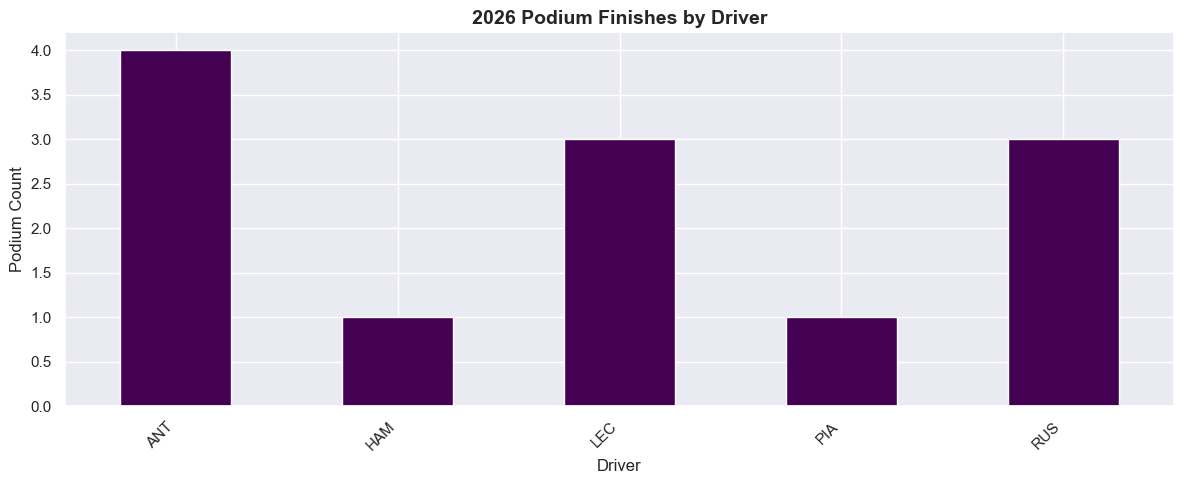

In [88]:
# Podium frequency by driver
podium_counts = (
    r_df[r_df["Podium"] == 1]
    .groupby("Driver")["Podium"]
    .count()
   
)

fig, ax = plt.subplots(figsize=(12, 5))
podium_counts.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("2026 Podium Finishes by Driver", fontsize=14, fontweight="bold")
ax.set_xlabel("Driver")
ax.set_ylabel("Podium Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

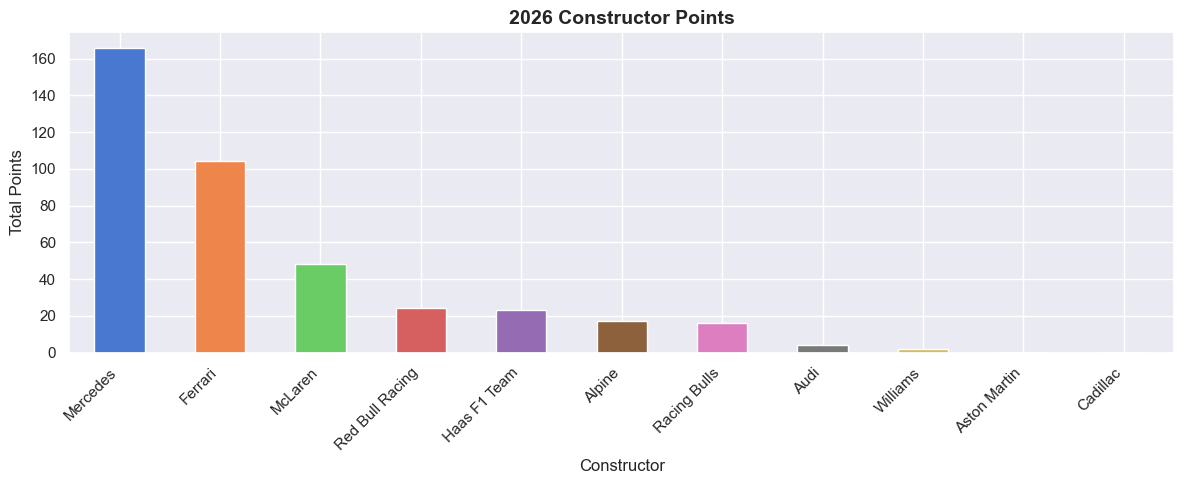

In [89]:
# Points distribution by team
import seaborn as sns
team_points = (
    r_df.groupby("Team")["Points"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
team_points.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(team_points)))
ax.set_title("2026 Constructor Points", fontsize=14, fontweight="bold")
ax.set_xlabel("Constructor")
ax.set_ylabel("Total Points")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [90]:
# checking for class imbalance
class_balance = r_df["Podium"].value_counts(normalize=True)
print("Target class balance:")
print(class_balance.rename({0: "Non-Podium", 1: "Podium"}).to_string())

Target class balance:
Podium
Non-Podium   0.864
Podium       0.136


# 3. Data Preparation
## 3.1 Feature Engineering

In [91]:
def engineer_features(r_df: pd.DataFrame, q_df: pd.DataFrame) -> pd.DataFrame:
    # Merge qualifying grid info onto race results
    quali_slim = q_df[
        ["Driver", "Event", "Position", "Q1_sec", "Q2_sec", "Q3_sec"]
    ].rename(columns={"Position": "GridPosition"})

    df = pd.merge(r_df, quali_slim, on=["Driver", "Event"], how="left")

    # Best qualifying time (min across Q1/Q2/Q3) ─────────────────────────
    df["QBest_sec"] = df[["Q1_sec", "Q2_sec", "Q3_sec"]].min(axis=1)

    # Cumulative driver statistics 
    # Sort by Event to maintain chronological order
    df.sort_values(["Driver", "Event"], inplace=True)

    df["DriverPodiumRateCum"] = (
        df.groupby("Driver")["Podium"]
          .transform(lambda x: x.expanding().mean().shift(1))
    )
    df["DriverAvgFinishCum"] = (
        df.groupby("Driver")["Position"]
          .transform(lambda x: x.expanding().mean().shift(1))
    )
    df["DriverPointsCum"] = (
        df.groupby("Driver")["Points"]
          .transform(lambda x: x.expanding().sum().shift(1))
    )

    # Cumulative constructor statistics
    df.sort_values(["Team", "Event"], inplace=True)

    df["TeamPodiumRateCum"] = (
        df.groupby("Team")["Podium"]
          .transform(lambda x: x.expanding().mean().shift(1))
    )
    df["TeamPointsCum"] = (
        df.groupby("Team")["Points"]
          .transform(lambda x: x.expanding().sum().shift(1))
    )

    df.reset_index(drop=True, inplace=True)
    return df


features_df = engineer_features(r_df, q_df)
print(f"Feature matrix shape: {features_df.shape}")
features_df.head(10)

Feature matrix shape: (88, 20)


,DriverNumber,Driver,Team,Position,Points,Status,Time,Event,Season,Podium,GridPosition,Q1_sec,Q2_sec,Q3_sec,QBest_sec,DriverPodiumRateCum,DriverAvgFinishCum,DriverPointsCum,TeamPodiumRateCum,TeamPointsCum
0,43,COL,Alpine,14.000,0.000,Lapped,0 days 00:00:08.487000,Australian Grand Prix,2026,0,16.000,81.200,81.270,NaN,81.200,NaN,NaN,NaN,NaN,NaN
1,10,GAS,Alpine,10.000,1.000,Lapped,0 days 00:00:29.027000,Australian Grand Prix,2026,0,14.000,81.138,80.501,NaN,80.501,NaN,NaN,NaN,0.000,0.000
2,43,COL,Alpine,10.000,1.000,Lapped,0 days 00:00:12.403000,Chinese Grand Prix,2026,0,12.000,93.634,93.357,NaN,93.357,0.000,14.000,0.000,0.000,1.000
3,10,GAS,Alpine,6.000,8.000,Finished,0 days 00:00:59.647000,Chinese Grand Prix,2026,0,7.000,93.788,93.003,92.873,92.873,0.000,10.000,1.000,0.000,2.000
4,43,COL,Alpine,16.000,0.000,Finished,0 days 00:01:05.773000,Japanese Grand Prix,2026,0,15.000,90.931,90.627,NaN,90.627,0.000,12.000,1.000,0.000,10.000
5,10,GAS,Alpine,7.000,6.000,Finished,0 days 00:00:32.340000,Japanese Grand Prix,2026,0,7.000,90.584,89.874,89.691,89.691,0.000,8.000,9.000,0.000,10.000
6,43,COL,Alpine,14.000,0.000,Lapped,0 days 00:00:08.487000,Saudi Arabian Grand Prix,2026,0,16.000,81.200,81.270,NaN,81.200,0.000,13.333,1.000,0.000,16.000
7,10,GAS,Alpine,10.000,1.000,Lapped,0 days 00:00:29.027000,Saudi Arabian Grand Prix,2026,0,14.000,81.138,80.501,NaN,80.501,0.000,7.667,15.000,0.000,16.000
8,14,ALO,Aston Martin,18.000,0.000,Retired,NaT,Australian Grand Prix,2026,0,17.000,81.969,NaN,NaN,81.969,NaN,NaN,NaN,NaN,NaN
9,18,STR,Aston Martin,17.000,0.000,Lapped,NaT,Australian Grand Prix,2026,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000


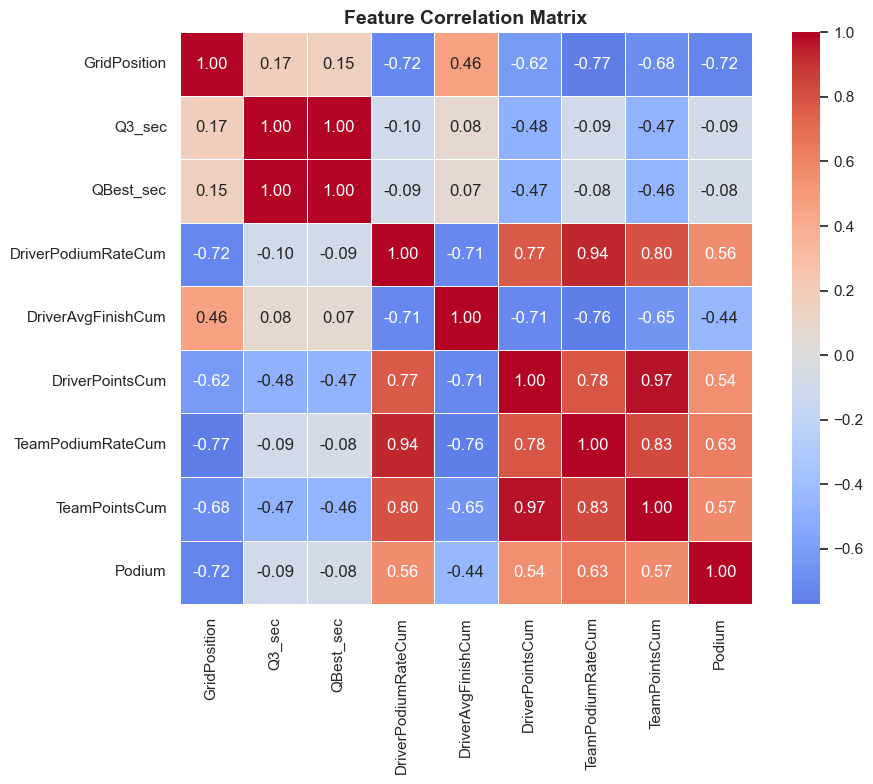

In [92]:
# Feature correlation heatmap
# Use the same data as the model (after dropna) to avoid NaN correlations
df_model = features_df[FEATURE_COLS + ["Podium"]].dropna()
NUMERIC_FEATURES = [
    "GridPosition", "Q3_sec", "QBest_sec",
    "DriverPodiumRateCum", "DriverAvgFinishCum", "DriverPointsCum",
    "TeamPodiumRateCum", "TeamPointsCum", "Podium"
]

corr_matrix = df_model[NUMERIC_FEATURES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [93]:
def build_model_dataset(
    features_df: pd.DataFrame,
    feature_cols: list,
    target_col: str = "Podium"
) -> tuple:
    df_model = features_df[feature_cols + [target_col]].dropna()
    X = df_model[feature_cols]
    y = df_model[target_col].astype(int)
    print(f"Model dataset: {X.shape[0]} rows * {X.shape[1]} features")
    print(f"Class distribution:\n{y.value_counts().rename({0:'Non-Podium',1:'Podium'})}")
    return X, y


FEATURE_COLS = [
    "GridPosition",
    "QBest_sec",
    "Q3_sec",
    "DriverPodiumRateCum",
    "DriverAvgFinishCum",
    "DriverPointsCum",
    "TeamPodiumRateCum",
    "TeamPointsCum",
]

X, y = build_model_dataset(features_df, FEATURE_COLS)

Model dataset: 29 rows * 8 features
Class distribution:
Podium
Non-Podium    20
Podium         9
Name: count, dtype: int64
